# Cell 1: Tai dataset khuon mat Nam/Nu

In [1]:
import kagglehub, os

path = kagglehub.dataset_download("ashwingupta3012/male-and-female-faces-dataset")
print("Path goc:", path)

# In cac thu muc co chua anh + so luong
print("\n--- Thu muc chua anh ---")
for root, dirs, fs in os.walk(path):
    n_img = len([f for f in fs if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    if n_img > 0:
        print(root, "->", n_img, "anh")

Using Colab cache for faster access to the 'male-and-female-faces-dataset' dataset.
Path goc: /kaggle/input/male-and-female-faces-dataset

--- Thu muc chua anh ---
/kaggle/input/male-and-female-faces-dataset/Male and Female face dataset/Male Faces -> 2720 anh
/kaggle/input/male-and-female-faces-dataset/Male and Female face dataset/Female Faces -> 2698 anh


# Cell 2: Nap thu vien

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tensorflow.keras.utils import load_img, img_to_array, to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

# Cell 3: Doc anh, gan nhan dua tren DUONG DAN TUONG DOI

In [3]:
# Cell 3 (tu du): tao all_files ngay trong cell roi gan nhan
import os
import numpy as np
from glob import glob
from tensorflow.keras.utils import load_img, img_to_array

IMG_SIZE = (64, 64)

# Tao lai danh sach file anh (khong phu thuoc cell khac)
all_files = (glob(path + '/**/*.jpg', recursive=True)
             + glob(path + '/**/*.jpeg', recursive=True)
             + glob(path + '/**/*.png', recursive=True))
print("Tong so anh:", len(all_files))

photos, labels = list(), list()
for file in all_files:
    # Chi lay ten thu muc NGAY TREN file anh
    parent = os.path.basename(os.path.dirname(file)).lower()
    if 'female' in parent:        # kiem tra female TRUOC
        output = 0   # Nu
    elif 'male' in parent:
        output = 1   # Nam
    else:
        continue
    try:
        image = load_img(file, target_size=IMG_SIZE)
        photos.append(img_to_array(image))
        labels.append(output)
    except:
        continue

photos = np.asarray(photos)
labels = np.asarray(labels)
print("Shape anh:", photos.shape)
print("Phan bo nhan (0=Nu, 1=Nam):", np.unique(labels, return_counts=True))

Tong so anh: 5400


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Shape anh: (5400, 64, 64, 3)
Phan bo nhan (0=Nu, 1=Nam): (array([0, 1]), array([2683, 2717]))


# Cell 4: Chuan hoa + chia train/test + one-hot

In [4]:
# Cell 4 (ban an toan): khong ghi de len 'photos'
photos_norm = photos.astype('float32') / 255.0   # bien moi

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    photos_norm, labels, test_size=0.2, random_state=42, stratify=labels)

y_train_oh = to_categorical(y_train, num_classes=2)
y_test_oh  = to_categorical(y_test, num_classes=2)
print("Train:", X_train.shape, "| Max pixel:", X_train.max())  # phai ~1.0

Train: (4320, 64, 64, 3) | Max pixel: 1.0


# Cell 5: Xay dung CNN (anh mau, 2 lop)

In [5]:
input_shape = (64, 64, 3)

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=2, activation='softmax'))   # 2 lop: Nu, Nam
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        25,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,482 (173.76 KB)

 Trainable params: 44,482 (173.76 KB)

 Non-trainable params: 0 (0.00 B)

# Cell 6: Compile va huan luyen

In [6]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train_oh,
                    validation_data=(X_test, y_test_oh),
                    epochs=10,
                    batch_size=32)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.6926 - loss: 0.5740 - val_accuracy: 0.7880 - val_loss: 0.4541
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 25s 185ms/step - accuracy: 0.8319 - loss: 0.3750 - val_accuracy: 0.7944 - val_loss: 0.4128
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.9009 - loss: 0.2518 - val_accuracy: 0.9370 - val_loss: 0.2139
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.9417 - loss: 0.1687 - val_accuracy: 0.9389 - val_loss: 0.1747
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step - accuracy: 0.9711 - loss: 0.1013 - val_accuracy: 0.9556 - val_loss: 0.1307
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 25s 188ms/step - accuracy: 0.9808 - loss: 0.0715 - val_accuracy: 0.9657 - val_loss: 0.1165
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.9877 - loss: 0.0497 - val_accuracy: 0.9778 - val_loss: 0.0844
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.9965 - loss: 0

# Cell 7: Danh gia + ve bieu do

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9880 - loss: 0.0687
Do chinh xac tren tap test: 98.8 %


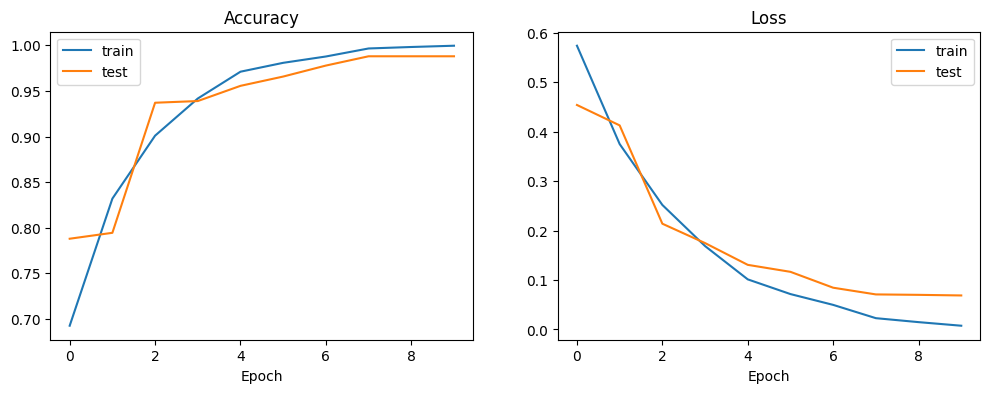

In [7]:
loss, acc = model.evaluate(X_test, y_test_oh)
print("Do chinh xac tren tap test:", round(acc*100, 2), "%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.show()

# Cell 8: Thu du doan 1 anh trong tap test

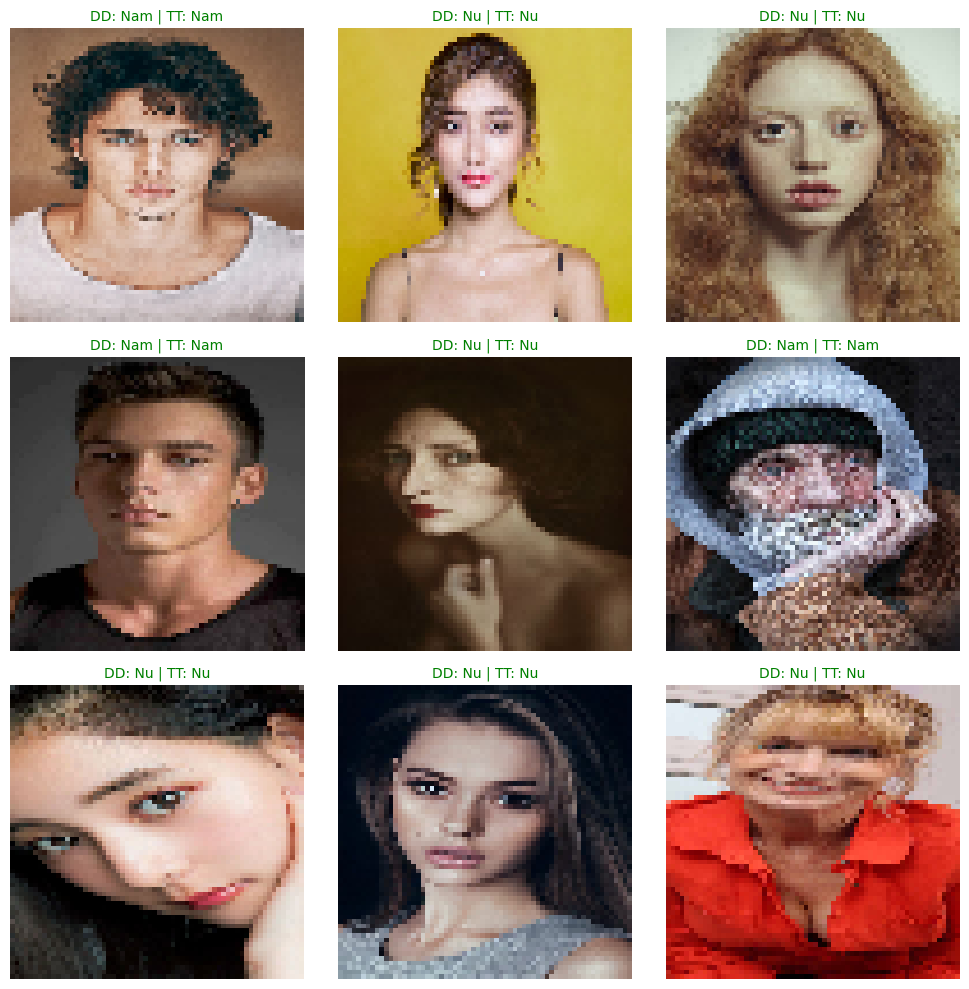

In [8]:
ten_lop = ['Nu', 'Nam']

so_anh = 9   # xem 9 anh
plt.figure(figsize=(10, 10))
for i in range(so_anh):
    idx = np.random.randint(0, len(X_test))
    anh = X_test[idx]
    du_doan = model.predict(anh.reshape(1, 64, 64, 3), verbose=0)
    nhan_du_doan = ten_lop[np.argmax(du_doan)]
    nhan_that = ten_lop[np.argmax(y_test_oh[idx])]

    # Neu doan dung -> mau xanh, doan sai -> mau do
    mau = 'green' if nhan_du_doan == nhan_that else 'red'

    plt.subplot(3, 3, i + 1)
    plt.imshow(anh)
    plt.title(f"DD: {nhan_du_doan} | TT: {nhan_that}", color=mau, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()